# Practical 06 — k-Nearest Neighbours (kNN) and Accuracy

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Syllabus:** *Implement k-Nearest Neighbours (kNN) and evaluate accuracy.*  
**Benchmark:** UCI Wine — 13 chemical assays, 3 cultivars.

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG (path, features, k)
        ↓
[3] 6-point 2-D HAND table (distances, k=1/3/5, uniform vs weighted)
        ↓
[4] Lazy learning / bias–variance / scaling theory
        ↓
[5] Vectorized NumPy KNNClassifier ≡ sklearn  →  [6] Wine pipeline + odd-k search
        ↓
[7] Error vs k, 3 decision boundaries, confusion matrix  →  [8] Viva
```

### Learning outcomes

1. Compute Euclidean distances from a query $x_q$ to six training points by hand; vote for $k=1,3,5$.
2. Contrast **uniform** majority vs **inverse-distance** weights (they can disagree).
3. Explain **lazy learning**, the **bias–variance** role of $k$, and **why we scale**.
4. Ship a vectorized NumPy `KNNClassifier` whose labels **match** `KNeighborsClassifier`.
5. Fit a leakage-safe `Pipeline(StandardScaler, kNN)` on Wine; pick $k^\star$ from a validation curve.

> **Why this matters:** kNN has **no training equation** — the data *are* the model. If you forget to scale, proline (thousands) drowns hue ($\sim 1$) and $k$ is meaningless.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or set `COLAB_DRIVE_CSV`.
3. No file: `sklearn.datasets.load_wine`.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#1e3a8a") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#eff6ff;border-left:4px solid #1d4ed8;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    print(f"\n{bar}\n {title}\n{bar}" if title else bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──────────► Wine CSV (or yours)
  FEATURE_COLUMNS ────► numeric predictors (None = all numeric except the target)
  TARGET_COLUMN ──────► cultivar / class label
  K_NEIGHBORS ────────► default k for the from-scratch / final model (odd preferred)
  DROP_COLUMNS ───────► IDs to ignore
```

The **grid search** still sweeps odd $k\in\{1,3,\ldots,25\}$; `K_NEIGHBORS` is the CONFIG default and a useful starting guess.

> **Why this matters:** $k$ is not a feature. Putting it in CONFIG makes the lab record say which neighbourhood size you used.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — swap CSV / features / k here                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/wine.csv"
TARGET_COLUMN = "cultivar"           # why: 3 wine types (class_0 / class_1 / class_2)
FEATURE_COLUMNS = None               # None = every numeric column except the target
K_NEIGHBORS = 5                      # why: odd k reduces 2-class ties; grid search still runs
DROP_COLUMNS: list[str] = []

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH         = {DATA_PATH}")
print(f"TARGET_COLUMN     = {TARGET_COLUMN}")
print(f"FEATURE_COLUMNS   = {FEATURE_COLUMNS}")
print(f"K_NEIGHBORS       = {K_NEIGHBORS}")
print(f"DROP_COLUMNS      = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local CSV exists: {_p.is_file()}  ({_p.resolve() if _p.exists() else _p})")



 DATASET CONFIG
DATA_PATH         = data/wine.csv
TARGET_COLUMN     = cultivar
FEATURE_COLUMNS   = None
K_NEIGHBORS       = 5
DROP_COLUMNS      = []
local CSV exists: True  (D:\LiamCodes\parul-mtech-coding\ml-practical\06_KNN_Classifier\data\wine.csv)


## 0. Environment, seed, and large high-DPI figures

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

SEED = 42  # why: split and PCA must be repeatable for the lab record
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid", palette="colorblind")

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| sklearn KNeighborsClassifier + Pipeline")
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | sklearn KNeighborsClassifier + Pipeline
SEED = 42


## 1. Load Wine from CONFIG

| Priority | Source |
|----------|--------|
| 1 | `DATA_PATH` |
| 2 | Colab Drive / upload |
| 3 | `sklearn.datasets.load_wine` |


In [4]:
def load_wine_table() -> tuple[pd.DataFrame, str]:
    path = Path(DATA_PATH)
    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_p = Path(COLAB_DRIVE_CSV)
        if drive_p.is_file():
            return pd.read_csv(drive_p), "gdrive"
    if IN_COLAB and COLAB_OFFER_UPLOAD and not path.is_file():
        saved = colab_upload_to(path)
        if saved is not None:
            return pd.read_csv(saved), "colab_upload"
    if path.is_file():
        return pd.read_csv(path), "local"  # why: version-controlled lab CSV
    bunch = load_wine(as_frame=True)
    frame = bunch.frame.copy()
    frame = frame.rename(columns={"target": TARGET_COLUMN})
    frame[TARGET_COLUMN] = frame[TARGET_COLUMN].map(lambda i: f"class_{int(i)}")
    return frame, "sklearn"


df, load_origin = load_wine_table()
for col in DROP_COLUMNS:
    if col in df.columns:
        df = df.drop(columns=[col])

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"TARGET_COLUMN={TARGET_COLUMN!r} not in {list(df.columns)}")

if FEATURE_COLUMNS is None:
    feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COLUMN]
else:
    missing = [c for c in FEATURE_COLUMNS if c not in df.columns]
    if missing:
        raise KeyError(f"FEATURE_COLUMNS missing: {missing}")
    feature_cols = list(FEATURE_COLUMNS)

_banner("1 · Loaded table")
print(f"origin = {load_origin} | shape = {df.shape} | features = {len(feature_cols)}")
print(f"classes = {sorted(df[TARGET_COLUMN].astype(str).unique())}")
display(df.head(5).style.set_caption("Wine (first 5 rows)").format(precision=3))


origin = local | shape = (178, 14) | features = 13
classes = ['class_0', 'class_1', 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,1065.000,class_0
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,1050.000,class_0
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,1185.000,class_0
3,14.370,1.950,2.500,16.800,113.000,3.850,3.490,0.240,2.180,7.800,0.860,3.450,1480.000,class_0
4,13.240,2.590,2.870,21.000,118.000,2.800,2.690,0.390,1.820,4.320,1.040,2.930,735.000,class_0


## 2. Hand calculation — six 2-D points and one query

Query $x_q=(0,0)$. Training set (class **A** or **B**):

| $i$ | $(x,y)$ | class | $d_2(x_q,x_i)=\sqrt{x^2+y^2}$ |
|----:|--------:|:-----:|------------------------------:|
| 1 | $(0.5,\ 0)$ | A | $0.500$ |
| 2 | $(2.0,\ 0)$ | B | $2.000$ |
| 3 | $(2.0,\ 0.2)$ | B | $\approx 2.010$ |
| 4 | $(0,\ 3)$ | A | $3.000$ |
| 5 | $(-4,\ 0)$ | B | $4.000$ |
| 6 | $(5,\ 5)$ | A | $\approx 7.071$ |

**Sort** by distance: $1,2,3,4,5,6$.

| $k$ | Neighbours | Uniform vote | Inverse-distance vote $w_i=1/d_i$ |
|----:|------------|--------------|-----------------------------------|
| 1 | A | **A** | **A** |
| 3 | A, B, B | **B** (2–1) | A: $2.00$; B: $0.50+0.50\approx 1.00$ → **A** |
| 5 | + A, B | B has 3, A has 2 → **B** | check in code |

> **Why this matters:** the same three neighbours can give **different labels** if you weight by $1/d$. Always write which vote you used. sklearn `weights='uniform'` vs `'distance'`.


In [5]:
_banner("2 · 6-point toy: distances, k=1/3/5, two voting rules")

X_toy = np.array(
    [
        [0.5, 0.0],
        [2.0, 0.0],
        [2.0, 0.2],
        [0.0, 3.0],
        [-4.0, 0.0],
        [5.0, 5.0],
    ],
    dtype=np.float64,
)
y_toy = np.array(["A", "B", "B", "A", "B", "A"])
xq = np.array([[0.0, 0.0]])

d = np.sqrt(np.sum((X_toy - xq) ** 2, axis=1))  # why: Euclidean in R^2 = Pythagoras
order = np.argsort(d, kind="mergesort")  # why: stable sort matches a careful hand ranking
work = pd.DataFrame(
    {
        "i": np.arange(1, 7),
        "x": X_toy[:, 0],
        "y": X_toy[:, 1],
        "class": y_toy,
        "d2 to xq": d,
        "rank": np.empty(6, dtype=int),
    }
)
work.loc[order, "rank"] = np.arange(1, 7)
display(
    work.sort_values("rank")
    .style.format({"x": "{:.2f}", "y": "{:.2f}", "d2 to xq": "{:.6f}"})
    .set_caption("Hand table: sort by Euclidean distance to x_q = (0, 0)")
)


def vote_uniform(labels: np.ndarray) -> str:
    vals, counts = np.unique(labels, return_counts=True)
    return str(vals[np.argmax(counts)])  # why: sklearn-style: first max in sorted unique labels


def vote_distance(labels: np.ndarray, dists: np.ndarray) -> str:
    w = 1.0 / np.maximum(dists, 1e-12)  # why: 1/d; clamp if a training point sits on the query
    scores = {}
    for lab, wi in zip(labels, w):
        scores[lab] = scores.get(lab, 0.0) + wi
    return max(scores, key=scores.get)


rows = []
for k in (1, 3, 5):
    ix = order[:k]
    rows.append(
        {
            "k": k,
            "neighbour classes": " ".join(y_toy[ix]),
            "uniform": vote_uniform(y_toy[ix]),
            "distance-weighted": vote_distance(y_toy[ix], d[ix]),
        }
    )
votes = pd.DataFrame(rows)
_why(
    "k=3: uniform says B (two B vs one A). Inverse-distance says A because the single A is much closer "
    "(d=0.5 vs d≈2). That is the whole point of this toy."
)
display(votes.style.set_caption("Votes for k = 1, 3, 5"))

# sklearn verification
for k, wname, col in [
    (1, "uniform", "uniform"),
    (3, "uniform", "uniform"),
    (3, "distance", "distance-weighted"),
    (5, "uniform", "uniform"),
    (5, "distance", "distance-weighted"),
]:
    sk = KNeighborsClassifier(n_neighbors=k, weights=wname, algorithm="brute")  # why: brute = exact distances
    sk.fit(X_toy, y_toy)
    pred = sk.predict(xq)[0]
    hand = votes.loc[votes["k"] == k, col].iloc[0]
    print(f"k={k:2d}  weights={wname:8s}  hand={hand}  sklearn={pred}  match={pred == hand}")
    assert pred == hand
print("Hand votes MATCH sklearn KNeighborsClassifier (brute, Euclidean).")


,i,x,y,class,d2 to xq,rank
0,1,0.50,0.00,A,0.500000,1
1,2,2.00,0.00,B,2.000000,2
2,3,2.00,0.20,B,2.009975,3
3,4,0.00,3.00,A,3.000000,4
4,5,-4.00,0.00,B,4.000000,5
5,6,5.00,5.00,A,7.071068,6


,k,neighbour classes,uniform,distance-weighted
0,1,A,A,A
1,3,A B B,B,A
2,5,A B B A B,B,A


k= 1  weights=uniform   hand=A  sklearn=A  match=True
k= 3  weights=uniform   hand=B  sklearn=B  match=True
k= 3  weights=distance  hand=A  sklearn=A  match=True
k= 5  weights=uniform   hand=B  sklearn=B  match=True
k= 5  weights=distance  hand=A  sklearn=A  match=True
Hand votes MATCH sklearn KNeighborsClassifier (brute, Euclidean).


## 3. Theory: lazy learning, $k$, and scaling

### 3.1 Non-parametric lazy learning

kNN **stores** $\{(x_i,y_i)\}_{i=1}^{n}$ and does the work at **query** time:

$$
\hat y(x_q)
=\operatorname{vote}\bigl\{\, y_i: i\in\mathcal{N}_k(x_q)\,\bigr\},
\qquad
\mathcal{N}_k(x_q)=\text{$k$ nearest $x_i$ under }d_2.
$$

There is no $\hat\beta$ to fit. Brute force is $O(nd)$ per query.

### 3.2 Bias–variance vs $k$

| $k$ | Behaviour | Bias | Variance |
|-----|-----------|------|----------|
| $1$ | Voronoi cells around each training point | low | high (overfit, noisy boundary) |
| moderate odd $k^\star$ | local majority | balanced | typically best **validation** error |
| $k\to n_{\mathrm{train}}$ | global majority class | high (underfit) | low |

Odd $k$ avoids 2-class ties; with 3 Wine cultivars ties can still happen.

### 3.3 Feature scaling is not optional

$$
\tilde x_j=\frac{x_j-\mu_j^{\mathrm{train}}}{\sigma_j^{\mathrm{train}}}.
$$

Fit $\mu,\sigma$ on **train only**, then `transform` validation and test. Otherwise proline dominates Euclidean distance.

**Uniform vote:** $\hat y=\arg\max_c \sum_{i\in\mathcal{N}_k}\mathbf{1}\{y_i=c\}$.

**Distance vote:** $w_i=1/d_i$ (sklearn `weights='distance'`; exact matches $d_i=0$ get infinite weight).

> **Why this matters:** changing $k$ is changing how **smooth** the classifier is — the same knob as tree depth, but in neighbour space.


## 4. Vectorized NumPy `KNNClassifier` (must match sklearn)


In [6]:
_banner("4 · From-scratch KNNClassifier")


class KNNClassifier:
    """Brute-force Euclidean kNN. Predictions are written to match sklearn (brute)."""

    def __init__(self, n_neighbors: int = 5, weights: str = "uniform"):
        self.n_neighbors = int(n_neighbors)  # why: neighbourhood size k
        self.weights = weights  # why: 'uniform' or 'distance'
        self.X_ = None
        self.y_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=np.float64)
        self.y_ = np.asarray(y)
        self.classes_ = np.unique(self.y_)  # why: sorted unique labels — sklearn tie-break order
        return self

    def _pairwise_l2(self, Xq: np.ndarray) -> np.ndarray:
        Xq = np.asarray(Xq, dtype=np.float64)
        # why: (nq, 1, d) − (1, n, d) → (nq, n) distances; no Python i,j loops
        return np.sqrt(np.sum((Xq[:, None, :] - self.X_[None, :, :]) ** 2, axis=-1))

    def predict(self, Xq) -> np.ndarray:
        D = self._pairwise_l2(Xq)
        k = min(self.n_neighbors, D.shape[1])
        part = np.argpartition(D, kth=k - 1, axis=1)[:, :k]  # why: k smallest, unsorted
        nq = D.shape[0]
        out = []
        for r in range(nq):
            ix = part[r]
            ix = ix[np.argsort(D[r, ix], kind="mergesort")]  # why: sort the k by distance
            labs = self.y_[ix]
            dist = D[r, ix]
            if self.weights == "uniform":
                # bincount over class indices; argmax → smallest label on ties (sklearn)
                mapped = np.searchsorted(self.classes_, labs)
                counts = np.bincount(mapped, minlength=len(self.classes_))
                out.append(self.classes_[int(np.argmax(counts))])
            else:
                w = np.where(dist == 0.0, np.inf, 1.0 / dist)  # why: exact match dominates
                scores = np.zeros(len(self.classes_))
                mapped = np.searchsorted(self.classes_, labs)
                for m, wi in zip(mapped, w):
                    scores[m] += wi
                out.append(self.classes_[int(np.argmax(scores))])
        return np.asarray(out)


# Match sklearn on the toy for k in CONFIG and {1,3,5}
for k in sorted({1, 3, 5, int(K_NEIGHBORS)}):
    for w in ("uniform", "distance"):
        ours = KNNClassifier(n_neighbors=k, weights=w).fit(X_toy, y_toy)
        sk = KNeighborsClassifier(n_neighbors=k, weights=w, algorithm="brute").fit(X_toy, y_toy)
        assert np.array_equal(ours.predict(xq), sk.predict(xq))
print("Toy: NumPy KNNClassifier == sklearn for uniform and distance, k in {1,3,5,K_NEIGHBORS}.")


Toy: NumPy KNNClassifier == sklearn for uniform and distance, k in {1,3,5,K_NEIGHBORS}.


## 5. Leakage-safe Wine pipeline and odd-$k$ grid search

```text
split  →  fit StandardScaler on TRAIN-inner only
       →  transform val / test with frozen μ, σ
       →  sweep odd k = 1,3,...,25 on VALIDATION error
       →  k* = argmin val error  (elbow / U-curve)
```

Hold out a **test** set before the sweep so $k^\star$ is not chosen on the numbers you report last.


In [7]:
_banner("5 · Split, scale, odd-k sweep")

le = LabelEncoder()
y = le.fit_transform(df[TARGET_COLUMN].astype(str))  # why: 0,1,2 for metrics / sklearn
X = df[feature_cols].to_numpy(dtype=np.float64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # why: frozen test — not used to pick k
    random_state=SEED,
    stratify=y,          # why: keep cultivar proportions
    shuffle=True,
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,      # why: validation fold for the k-curve
    random_state=SEED,
    stratify=y_trainval,
    shuffle=True,
)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)    # why: μ, σ from inner train only
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

ks = list(range(1, 26, 2))  # why: odd k from 1 to 25 as specified
err_tr, err_val = [], []
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k, weights="uniform", algorithm="brute")
    clf.fit(X_tr_s, y_tr)
    err_tr.append(1.0 - accuracy_score(y_tr, clf.predict(X_tr_s)))
    err_val.append(1.0 - accuracy_score(y_val, clf.predict(X_val_s)))

k_star = int(ks[int(np.argmin(err_val))])  # why: elbow = lowest validation error
print(f"k* (min validation error) = {k_star}   |  CONFIG K_NEIGHBORS = {K_NEIGHBORS}")

# Refit scaler + kNN on full trainval with k*
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),  # why: pipeline fits scaler on whatever .fit sees
        ("knn", KNeighborsClassifier(n_neighbors=k_star, weights="uniform")),
    ]
)
pipe.fit(X_trainval, y_trainval)
yhat = pipe.predict(X_test)

# Scratch vs sklearn on scaled inner-train → val
ours = KNNClassifier(n_neighbors=k_star, weights="uniform").fit(X_tr_s, y_tr)
sk = KNeighborsClassifier(n_neighbors=k_star, weights="uniform", algorithm="brute").fit(X_tr_s, y_tr)
match = np.array_equal(ours.predict(X_val_s), sk.predict(X_val_s))
print("NumPy KNNClassifier == sklearn on scaled Wine validation:", match)
assert match

_why(
    f"k*= {k_star} was chosen on validation, then the pipeline was refit on train+val. "
    "The test accuracy below is the honest number for the lab record."
)
print("test accuracy =", f"{accuracy_score(y_test, yhat):.4f}")
print(classification_report(y_test, yhat, target_names=le.classes_, digits=3))


k* (min validation error) = 1   |  CONFIG K_NEIGHBORS = 5


NumPy KNNClassifier == sklearn on scaled Wine validation: True


test accuracy = 0.9556
              precision    recall  f1-score   support

     class_0      0.938     1.000     0.968        15
     class_1      1.000     0.889     0.941        18
     class_2      0.923     1.000     0.960        12

    accuracy                          0.956        45
   macro avg      0.954     0.963     0.956        45
weighted avg      0.959     0.956     0.955        45



## 6. Publication-quality figures

### 6.1 Train vs validation error rate versus $k$ (find $k^\star$)


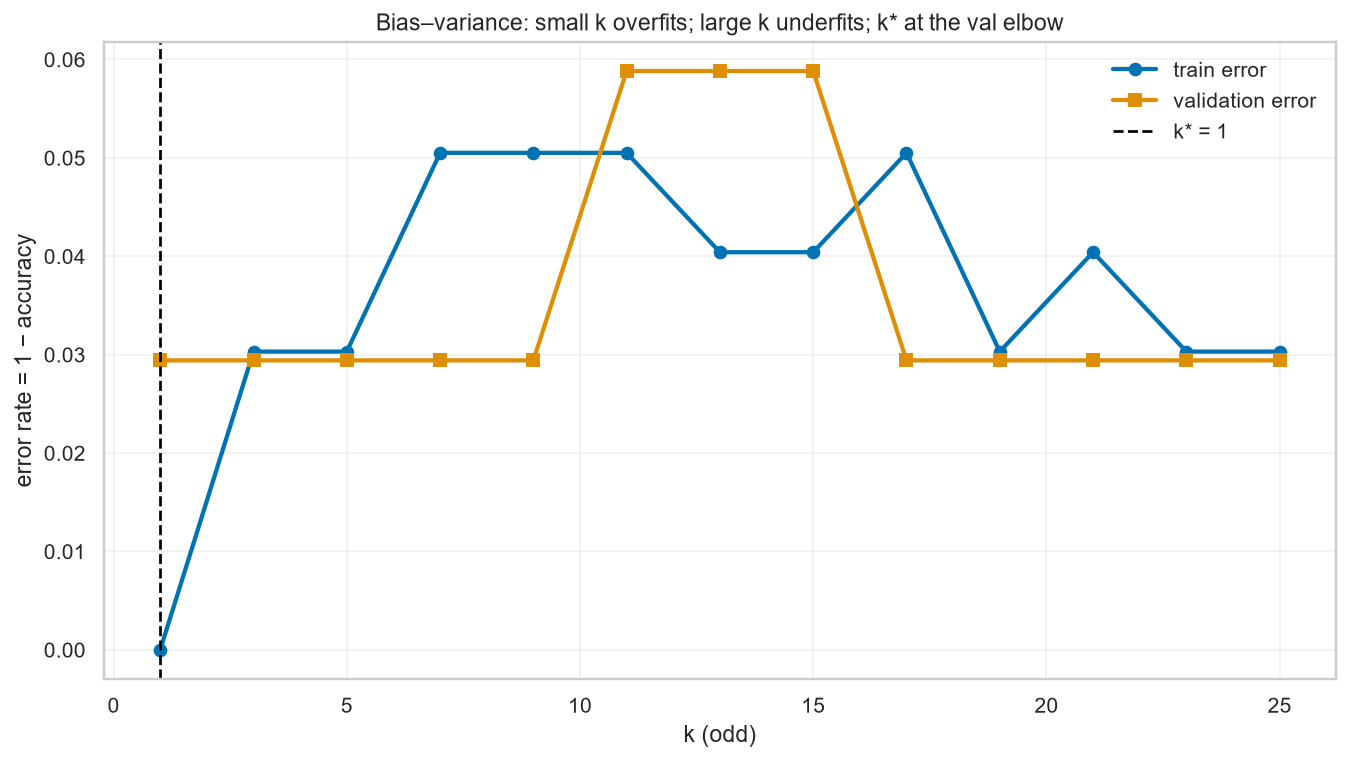

In [8]:
_banner("6.1 · Error vs k")

fig, ax = plt.subplots(figsize=(9.8, 5.6))
ax.plot(ks, err_tr, marker="o", lw=2.2, label="train error")
ax.plot(ks, err_val, marker="s", lw=2.2, label="validation error")
ax.axvline(k_star, color="black", ls="--", lw=1.4, label=f"k* = {k_star}")
ax.set_xlabel("k (odd)")
ax.set_ylabel("error rate = 1 − accuracy")
ax.set_title("Bias–variance: small k overfits; large k underfits; k* at the val elbow")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### 6.2 Three 2-D decision regions (PCA plane): $k=1$ / $k^\star$ / large $k$

Wine lives in $\mathbb{R}^{13}$. We **visualise** neighbours in the first two principal components of the **scaled training** cloud. Boundaries are kNN **in that plane**, not a claim that two PCs replace 13 assays.


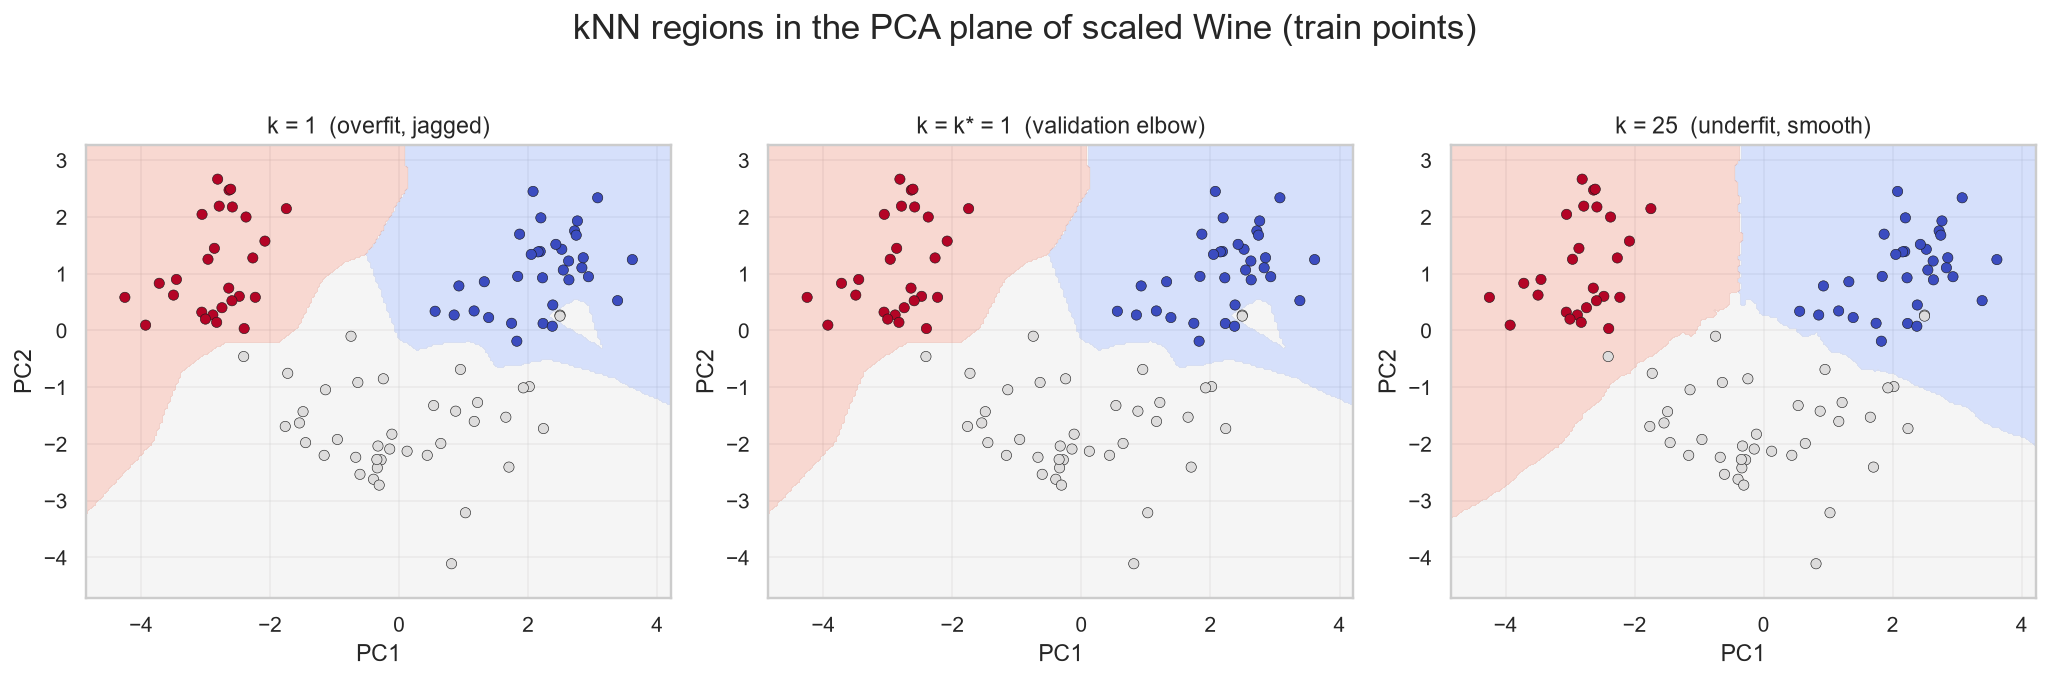

In [9]:
_banner("6.2 · Decision boundaries")

pca = PCA(n_components=2, random_state=SEED)
Z_tr = pca.fit_transform(X_tr_s)  # why: 2-D picture only; scaler already applied
Z_val = pca.transform(X_val_s)

ks_panel = [1, k_star, max(ks)]  # why: overfit / elbow / underfit
titles = [
    "k = 1  (overfit, jagged)",
    f"k = k* = {k_star}  (validation elbow)",
    f"k = {max(ks)}  (underfit, smooth)",
]

pad = 0.6
x_min, x_max = Z_tr[:, 0].min() - pad, Z_tr[:, 0].max() + pad
y_min, y_max = Z_tr[:, 1].min() - pad, Z_tr[:, 1].max() + pad
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 220),  # why: dense enough for a clean region plot
    np.linspace(y_min, y_max, 220),
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.7))
cmap = plt.colormaps.get_cmap("coolwarm")
for ax, k, title in zip(axes, ks_panel, titles):
    knn2 = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn2.fit(Z_tr, y_tr)
    zz = knn2.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.28, levels=np.arange(-0.5, 3.5, 1), cmap=cmap)
    ax.scatter(Z_tr[:, 0], Z_tr[:, 1], c=y_tr, cmap=cmap, s=28, edgecolors="k", linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
fig.suptitle("kNN regions in the PCA plane of scaled Wine (train points)", y=1.03)
fig.tight_layout()
plt.show()


### 6.3 Confusion matrix (test) and a compact metric table


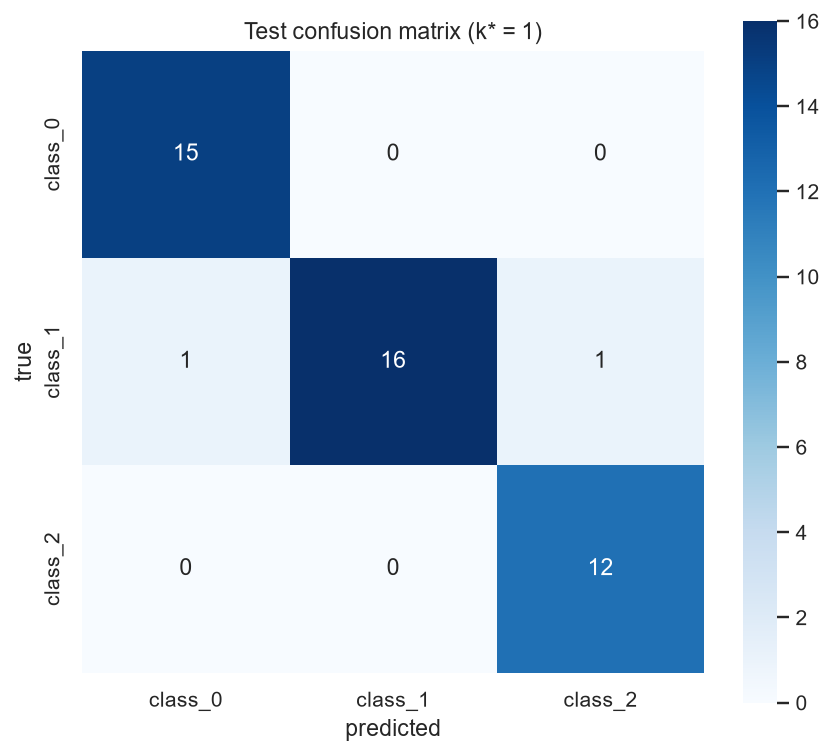

,precision,recall,f1-score,support
class_0,0.938,1.000,0.968,15.000
class_1,1.000,0.889,0.941,18.000
class_2,0.923,1.000,0.960,12.000
accuracy,0.956,0.956,0.956,0.956
macro avg,0.954,0.963,0.956,45.000
weighted avg,0.959,0.956,0.955,45.000


In [10]:
_banner("6.3 · Confusion matrix")

cm = confusion_matrix(y_test, yhat)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
sns.heatmap(
    cm,
    ax=ax,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    square=True,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Test confusion matrix (k* = {k_star})")
fig.tight_layout()
plt.show()

rep = classification_report(y_test, yhat, target_names=le.classes_, output_dict=True)
rep_df = pd.DataFrame(rep).T
display(rep_df.style.format("{:.3f}").set_caption("Test classification report"))


## 7. Viva-voce (indicative Q&A)

**Q1. Why is kNN called lazy / non-parametric?**  
**A.** It does not estimate a fixed $\beta$. It stores the training set and searches neighbours at query time.

**Q2. Write Euclidean distance in $\mathbb{R}^{d}$.**  
**A.** $d_2(x,z)=\sqrt{\sum_j(x_j-z_j)^2}$.

**Q3. Uniform vs inverse-distance votes?**  
**A.** Uniform: each of $k$ neighbours has weight 1. Distance: $w_i=1/d_i$ (exact matches dominate). They can disagree, as in the 6-point toy.

**Q4. What happens as $k=1$ vs $k=n$?**  
**A.** $k=1$: Voronoi / overfit. $k=n$: always the global majority — underfit.

**Q5. Why odd $k$ in binary problems?**  
**A.** Avoids 2–2 ties. With 3 Wine classes ties remain possible.

**Q6. Why `StandardScaler` before kNN?**  
**A.** $\ell_2$ mixes units. Unscaled proline swamps hue. Fit $\mu,\sigma$ on **train** only.

**Q7. Why not pick $k$ on the test set?**  
**A.** That leaks the number you will brag about. Use validation (or CV), then report test once.

**Q8. How did we implement pairwise distances without Python loops?**  
**A.** Broadcast `Xq[:, None, :] - X[None, :, :]` then root-sum-square.

**Q9. How does sklearn break uniform-vote ties?**  
**A.** Among labels with maximal count, it takes the class with the **smallest index** in `classes_` (sorted unique labels).

**Q10. What is the “elbow” on the error-vs-$k$ plot?**  
**A.** The $k$ where validation error is smallest (or stops improving) — our $k^\star$.

**Q11. Why PCA for decision regions?**  
**A.** Wine is 13-D. Two PCs are a **picture**, not the production metric. Production kNN still uses all scaled features.

**Q12. Train error at $k=1$ is often 0. Is that good?**  
**A.** No — every point is its own neighbour. Watch **validation / test** error instead.


## 8. Conclusion

This practical locked in **neighbourhood classification**:

1. **CONFIG** — `DATA_PATH`, `FEATURE_COLUMNS`, `TARGET_COLUMN`, `K_NEIGHBORS`, `DROP_COLUMNS`.
2. **Hand table** — six points, Euclidean ranks, $k=1,3,5$, uniform vs $1/d$ (sklearn-verified).
3. **Theory** — lazy learning, bias–variance vs $k$, train-only scaling.
4. **NumPy `KNNClassifier`** — matches sklearn brute Euclidean on toy and Wine val.
5. **Pipeline** — odd-$k$ sweep, $k^\star$ elbow, test confusion matrix.
6. **Figures** — error vs $k$, three PCA boundaries, heatmap.

**Next practical:** PCA — still without touching `extra/`.

### Submission checklist

- [ ] Re-run all cells on `ml-lab-kernel`
- [ ] Paste the k=3 uniform vs distance labels from the toy
- [ ] Record $k^\star$ and **test** accuracy
